# Qini and AUUC evaluation



In [5]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

os.chdir('/Users/beza/hillstrom-email-uplift-modeling')
print("Working directory:", os.getcwd())

Working directory: /Users/beza/hillstrom-email-uplift-modeling


In [6]:
model_files = {
    'Response Baseline': 'outputs/model_results/response_baseline_results.json',
    'S-Learner': 'outputs/model_results/s_learner_results.json',
    'T-Learner': 'outputs/model_results/t_learner_results.json',
    'X-Learner': 'outputs/model_results/x_learner_results.json',
    'Causal Forest': 'outputs/model_results/causal_forest_results.json',
}

results = {}
for name, path in model_files.items():
    with open(path) as f:
        results[name] = json.load(f)
    print(f"Loaded {name}")

Loaded Response Baseline
Loaded S-Learner
Loaded T-Learner
Loaded X-Learner
Loaded Causal Forest


In [7]:
rb_preds = pd.read_csv('outputs/predictions/response_baseline_predictions.csv')
s_preds = pd.read_csv('outputs/predictions/s_learner_predictions.csv')

treatment_test = pd.read_csv('data/processed/treatment_test.csv').squeeze()
y_test = pd.read_csv('data/processed/y_test.csv').squeeze()

print("rb_preds:", rb_preds.shape, rb_preds.columns.tolist())
print("s_preds:", s_preds.shape, s_preds.columns.tolist())
print("treatment_test:", treatment_test.shape)
print("y_test:", y_test.shape)

print("\nRB y_true matches canonical y_test:", (rb_preds['y_true'].values == y_test.values).all())
print("S-Learner y_true matches canonical y_test:", (s_preds['y_true'].values == y_test.values).all())

rb_preds: (16000, 5) ['y_true', 'logistic_proba', 'logistic_pred', 'xgboost_proba', 'xgboost_pred']
s_preds: (16000, 4) ['y_true', 'treatment', 'tau_hat_lr', 'tau_hat_xgb']
treatment_test: (16000,)
y_test: (16000,)

RB y_true matches canonical y_test: True
S-Learner y_true matches canonical y_test: True


In [8]:
print(results['X-Learner']['qini_score'])
print(results['X-Learner']['auuc_score'])

{'X-Learner': 0.04995950953898738}
{'X-Learner': 0.5510278854110819}


In [9]:
from sklift.metrics import qini_auc_score, uplift_auc_score

T_te = treatment_test.values
Y_te = y_test.values


rb_lgr_qini = qini_auc_score(Y_te, rb_preds['logistic_proba'].values, T_te)
rb_lgr_auuc = uplift_auc_score(Y_te, rb_preds['logistic_proba'].values, T_te)
rb_xgb_qini = qini_auc_score(Y_te, rb_preds['xgboost_proba'].values, T_te)
rb_xgb_auuc = uplift_auc_score(Y_te, rb_preds['xgboost_proba'].values, T_te)

print(f"Response Baseline (logistic): Qini={rb_lgr_qini:.4f}  AUUC={rb_lgr_auuc:.4f}")
print(f"Response Baseline (xgboost):  Qini={rb_xgb_qini:.4f}  AUUC={rb_xgb_auuc:.4f}")


s_lr_qini = qini_auc_score(s_preds['y_true'].values, s_preds['tau_hat_lr'].values, s_preds['treatment'].values)
s_lr_auuc = uplift_auc_score(s_preds['y_true'].values, s_preds['tau_hat_lr'].values, s_preds['treatment'].values)
s_xgb_qini = qini_auc_score(s_preds['y_true'].values, s_preds['tau_hat_xgb'].values, s_preds['treatment'].values)
s_xgb_auuc = uplift_auc_score(s_preds['y_true'].values, s_preds['tau_hat_xgb'].values, s_preds['treatment'].values)

print(f"\nS-Learner (logistic): Qini={s_lr_qini:.4f}  AUUC={s_lr_auuc:.4f}")
print(f"S-Learner (xgboost):   Qini={s_xgb_qini:.4f}  AUUC={s_xgb_auuc:.4f}")

Response Baseline (logistic): Qini=0.0340  AUUC=0.0208
Response Baseline (xgboost):  Qini=0.0314  AUUC=0.0192

S-Learner (logistic): Qini=0.0338  AUUC=0.0207
S-Learner (xgboost):   Qini=0.0189  AUUC=0.0116


In [10]:
print("X-Learner qini_score raw:", results['X-Learner']['qini_score'])
print("X-Learner auuc_score raw:", results['X-Learner']['auuc_score'])

X-Learner qini_score raw: {'X-Learner': 0.04995950953898738}
X-Learner auuc_score raw: {'X-Learner': 0.5510278854110819}


In [11]:
rows = [
    {'Model': 'Response Baseline', 'Base Learner': 'logistic_regression',
     'Qini Score': rb_lgr_qini, 'AUUC Score': rb_lgr_auuc,
     'ROC AUC': results['Response Baseline']['logistic_regression']['roc_auc']},
    {'Model': 'Response Baseline', 'Base Learner': 'xgboost',
     'Qini Score': rb_xgb_qini, 'AUUC Score': rb_xgb_auuc,
     'ROC AUC': results['Response Baseline']['xgboost']['roc_auc']},

    {'Model': 'S-Learner', 'Base Learner': 'logistic_regression',
     'Qini Score': s_lr_qini, 'AUUC Score': s_lr_auuc, 'ROC AUC': np.nan},
    {'Model': 'S-Learner', 'Base Learner': 'xgboost',
     'Qini Score': s_xgb_qini, 'AUUC Score': s_xgb_auuc, 'ROC AUC': np.nan},

    {'Model': 'T-Learner', 'Base Learner': 'logistic_regression',
     'Qini Score': results['T-Learner']['lgr_t_learner']['qini_score'],
     'AUUC Score': results['T-Learner']['lgr_t_learner']['auuc_score'], 'ROC AUC': np.nan},
    {'Model': 'T-Learner', 'Base Learner': 'xgboost',
     'Qini Score': results['T-Learner']['xgb_t_learner']['qini_score'],
     'AUUC Score': results['T-Learner']['xgb_t_learner']['auuc_score'], 'ROC AUC': np.nan},
    {'Model': 'T-Learner', 'Base Learner': 'random_forest',
     'Qini Score': results['T-Learner']['rf_t_learner']['qini_score'],
     'AUUC Score': results['T-Learner']['rf_t_learner']['auuc_score'], 'ROC AUC': np.nan},

    {'Model': 'X-Learner', 'Base Learner': results['X-Learner'].get('model', 'default'),
     'Qini Score': results['X-Learner']['qini_score']['X-Learner'],
     'AUUC Score': results['X-Learner']['auuc_score']['X-Learner'], 'ROC AUC': np.nan},

    {'Model': 'Causal Forest', 'Base Learner': 'UpliftRandomForest',
     'Qini Score': results['Causal Forest']['causal_forest']['qini_score'],
     'AUUC Score': results['Causal Forest']['causal_forest']['auuc_score'], 'ROC AUC': np.nan},
]

comparison_df = pd.DataFrame(rows)
comparison_df = comparison_df.sort_values('Qini Score', ascending=False).reset_index(drop=True)
comparison_df

,Model,Base Learner,Qini Score,AUUC Score,ROC AUC
0,T-Learner,logistic_regression,0.089040,0.591958,NaN
1,X-Learner,x_learner,0.049960,0.551028,NaN
2,T-Learner,random_forest,0.044387,0.545956,NaN
3,T-Learner,xgboost,0.044277,0.545804,NaN
4,Response Baseline,logistic_regression,0.033983,0.020811,0.624535
5,S-Learner,logistic_regression,0.033811,0.020727,NaN
6,Response Baseline,xgboost,0.031354,0.019181,0.614998
7,S-Learner,xgboost,0.018854,0.011641,NaN
8,Causal Forest,UpliftRandomForest,0.003177,0.002235,NaN


In [12]:
x_preds = pd.read_csv('outputs/predictions/tau_hat_x.csv')
print(x_preds.columns.tolist())
print(x_preds.head())

t_preds = pd.read_csv('outputs/predictions/t_learner_predictions.csv')
print("\n", t_preds.columns.tolist())
print(t_preds.head())

['index', 'tau_hat_x']
   index  tau_hat_x
0      0   0.049836
1      1   0.032668
2      2   0.039154
3      3   0.038558
4      4   0.037131

 ['y_true', 'treatment', 'segment', 'lgr_pred_visit_if_treated', 'lgr_pred_visit_if_control', 'lgr_predicted_uplift', 'xgb_pred_visit_if_treated', 'xgb_pred_visit_if_control', 'xgb_predicted_uplift', 'rf_pred_visit_if_treated', 'rf_pred_visit_if_control', 'rf_predicted_uplift']
   y_true  treatment        segment  lgr_pred_visit_if_treated  \
0       0          0      No E-Mail                   0.100280   
1       0          1  Womens E-Mail                   0.210531   
2       0          1    Mens E-Mail                   0.142879   
3       1          0      No E-Mail                   0.160354   
4       1          1    Mens E-Mail                   0.192372   

   lgr_pred_visit_if_control  lgr_predicted_uplift  xgb_pred_visit_if_treated  \
0                   0.053483              0.046797                   0.101355   
1                 

In [13]:
print("x_preds length:", len(x_preds))
print("y_test length:", len(y_test))

x_preds length: 16000
y_test length: 16000


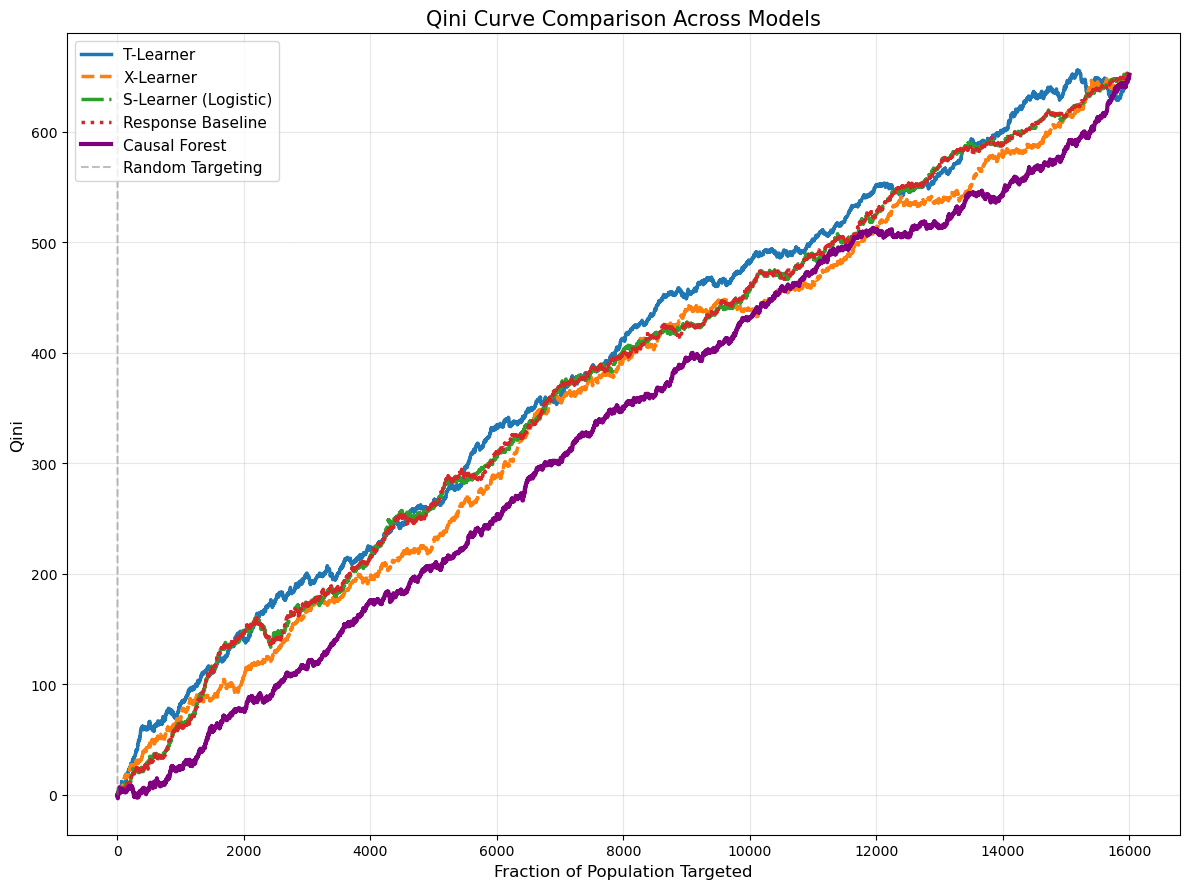

In [21]:
from sklift.metrics import qini_curve, perfect_qini_curve, uplift_curve, perfect_uplift_curve

plt.figure(figsize=(12, 9))

# T-Learner
frac, vals = qini_curve(t_preds['y_true'].values, t_preds['lgr_predicted_uplift'].values, t_preds['treatment'].values)
plt.plot(frac, vals, label='T-Learner', linewidth=2.5, linestyle='-')

# X-Learner
frac, vals = qini_curve(y_test.values, x_preds['tau_hat_x'].values, treatment_test.values)
plt.plot(frac, vals, label='X-Learner', linewidth=2.5, linestyle='--')

# S-Learner
frac, vals = qini_curve(s_preds['y_true'].values, s_preds['tau_hat_lr'].values, s_preds['treatment'].values)
plt.plot(frac, vals, label='S-Learner (Logistic)', linewidth=2.5, linestyle='-.')

# Response Baseline
frac, vals = qini_curve(rb_preds['y_true'].values, rb_preds['logistic_proba'].values, treatment_test.values)
plt.plot(frac, vals, label='Response Baseline', linewidth=2.5, linestyle=':')
cf_preds = pd.read_csv('outputs/predictions/causal_forest_predictions.csv')

# Causal Forest
cf_preds = pd.read_csv('outputs/predictions/causal_forest_predictions.csv')
frac, vals = qini_curve(cf_preds['y_true'].values, cf_preds['cf_predicted_uplift'].values, cf_preds['treatment'].values)
plt.plot(frac, vals, label='Causal Forest', linewidth=3, linestyle='-', color='purple')

# Random targeting reference line
plt.plot([0, 1], [0, vals[-1]], color='gray', linestyle='--', label='Random Targeting', alpha=0.5)

plt.xlabel('Fraction of Population Targeted', fontsize=12)
plt.ylabel('Qini', fontsize=12)
plt.title('Qini Curve Comparison Across Models', fontsize=15)
plt.legend(fontsize=11, loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/figures/model_comparison_qini_curves.png', dpi=200)
plt.show()

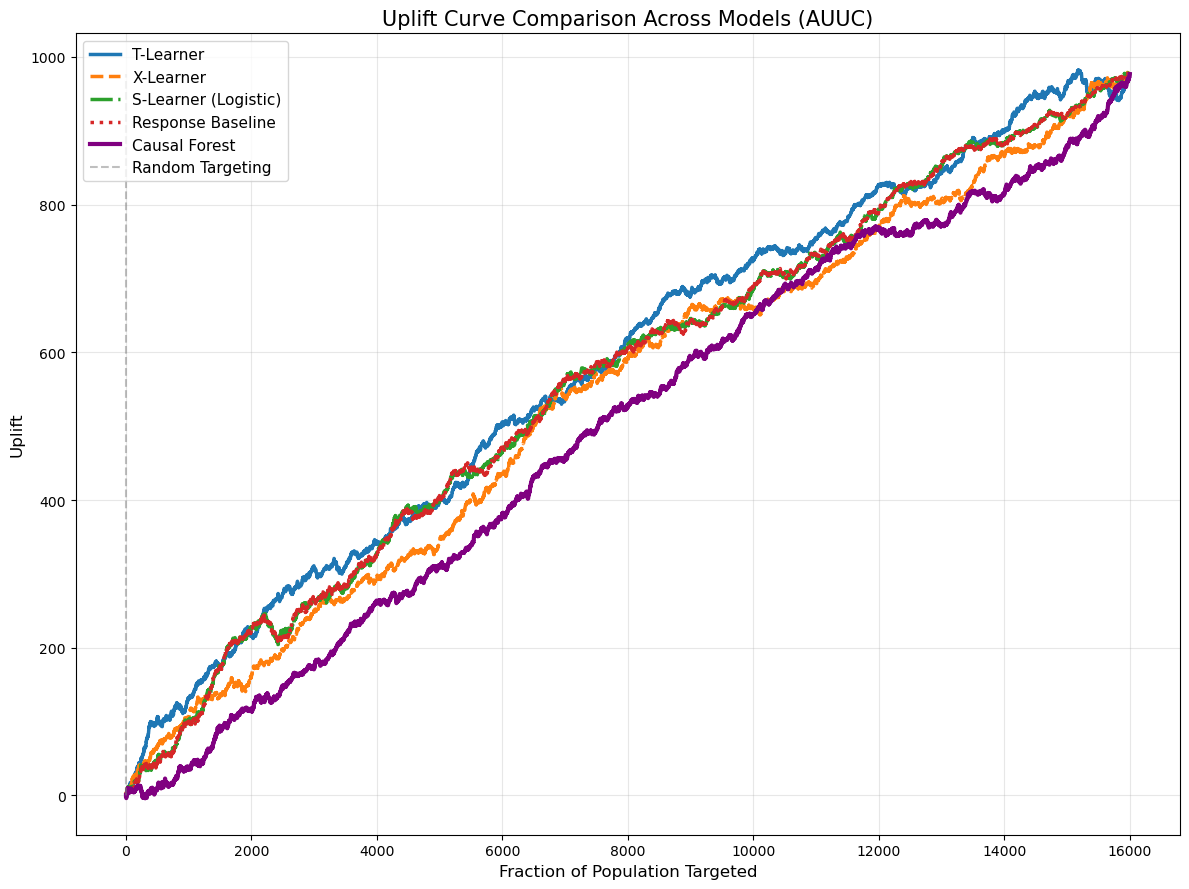

In [22]:
plt.figure(figsize=(12, 9))

# T-Learner
frac, vals = uplift_curve(t_preds['y_true'].values, t_preds['lgr_predicted_uplift'].values, t_preds['treatment'].values)
plt.plot(frac, vals, label='T-Learner', linewidth=2.5, linestyle='-')

# X-Learner
frac, vals = uplift_curve(y_test.values, x_preds['tau_hat_x'].values, treatment_test.values)
plt.plot(frac, vals, label='X-Learner', linewidth=2.5, linestyle='--')

# S-Learner
frac, vals = uplift_curve(s_preds['y_true'].values, s_preds['tau_hat_lr'].values, s_preds['treatment'].values)
plt.plot(frac, vals, label='S-Learner (Logistic)', linewidth=2.5, linestyle='-.')

# Response Baseline
frac, vals = uplift_curve(rb_preds['y_true'].values, rb_preds['logistic_proba'].values, treatment_test.values)
plt.plot(frac, vals, label='Response Baseline', linewidth=2.5, linestyle=':')

# Causal Forest
frac, vals = uplift_curve(cf_preds['y_true'].values, cf_preds['cf_predicted_uplift'].values, cf_preds['treatment'].values)
plt.plot(frac, vals, label='Causal Forest', linewidth=3, linestyle='-', color='purple')

# Random targeting reference line
plt.plot([0, 1], [0, vals[-1]], color='gray', linestyle='--', label='Random Targeting', alpha=0.5)

plt.xlabel('Fraction of Population Targeted', fontsize=12)
plt.ylabel('Uplift', fontsize=12)
plt.title('Uplift Curve Comparison Across Models (AUUC)', fontsize=15)
plt.legend(fontsize=11, loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/figures/model_comparison_uplift_curves.png', dpi=200)
plt.show()

## Model Comparison Results

The table above ranks all five uplift modeling approaches by Qini score on the held out test set. The T Learner using logistic regression as its base learner achieved the highest Qini score at 0.089 and the highest AUUC at 0.592, making it the strongest performer in this comparison. The X Learner followed in second place with a Qini score of 0.050, and the T Learner variants using random forest and XGBoost base learners came in third and fourth at 0.044 each.

The Response Baseline and S Learner models, which are naive or single model approaches rather than dedicated causal estimators, produced noticeably lower Qini scores in the 0.019 to 0.034 range. This is expected, since these models were not designed to isolate treatment effects the way the T Learner and X Learner were.

The Causal Forest model produced a Qini score of 0.0317 and an AUUC of 0.0022 on the single test split, placing it near the bottom of this ranking. However, the five fold cross validation results for the Causal Forest showed a mean Qini score of 0.0165, considerably higher than its single split result, suggesting that a single train test split may understate its true performance and that the model is more sensitive to how the data is partitioned than the other approaches.

Overall, the T Learner family of models delivered the most consistent and highest performing uplift estimates in this project, while the Causal Forest showed promise under cross validation but did not outperform the simpler T Learner approach on this dataset.